## Import & Define Constant Variable & Function

In [109]:
from json import dump, load

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer, MinMaxScaler

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

In [110]:
PATH_MODEL_PERFORMANCE = "model_performance.json"
DROPPED_COL = []
# "passengerid", "cabin", "ticket"

In [111]:
with open(PATH_MODEL_PERFORMANCE, 'r') as file:
    models_performance = load(file)

In [112]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')


def encode_OHE(X, fit=True):
    categorical_columns = X.select_dtypes("object").columns

    one_hot_encoded = encoder.fit_transform(
        X[categorical_columns]) if fit else encoder.transform(X[categorical_columns])

    one_hot_X = pd.DataFrame(
        one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

    X_encoded = pd.concat([X.reset_index(
        drop=True), one_hot_X.reset_index(drop=True)], axis=1)

    X_encoded = X_encoded.drop(categorical_columns, axis=1)
    return X_encoded

## EDA

In [113]:
df_train = pd.read_csv(r"datasets\train.csv")
df_test = pd.read_csv(r"datasets\test.csv")

In [114]:
print(f"Shape of train: {df_train.shape}")
print(f"Shape of test: {df_test.shape}")

Shape of train: (891, 12)
Shape of test: (418, 11)


In [115]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [116]:
df_train = df_train.rename(columns={col: col.lower()
                           for col in df_train.columns})
df_test = df_test.rename(columns={col: col.lower() for col in df_test.columns})

In [117]:
X_train = df_train.drop(["survived", *DROPPED_COL], axis=1)
y_train = df_train["survived"]

In [118]:
print(
    f"Pct of Survived vs Not Survived:\n{y_train.value_counts(normalize=True)}")

Pct of Survived vs Not Survived:
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [119]:
categorical_cols = X_train.select_dtypes(include="object").columns
numerical_cols = X_train.select_dtypes(include="number").columns
print(f"Categorical Columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical Columns ({len(numerical_cols)}): {numerical_cols}")

Categorical Columns (5): Index(['name', 'sex', 'ticket', 'cabin', 'embarked'], dtype='object')
Numerical Columns (6): Index(['passengerid', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')


In [120]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   name         891 non-null    object 
 3   sex          891 non-null    object 
 4   age          714 non-null    float64
 5   sibsp        891 non-null    int64  
 6   parch        891 non-null    int64  
 7   ticket       891 non-null    object 
 8   fare         891 non-null    float64
 9   cabin        204 non-null    object 
 10  embarked     889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [121]:
X_train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
passengerid,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
cabin,204,147,G6,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Vis

<Axes: >

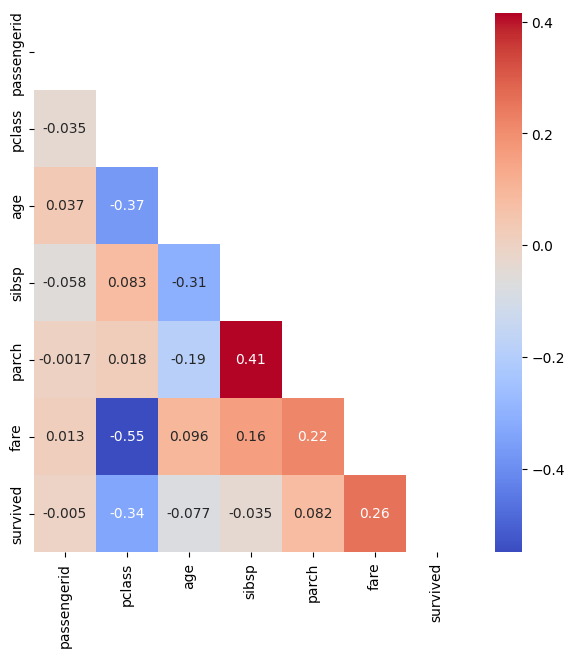

In [56]:
corr = pd.concat([X_train, y_train], axis=1).corr(numeric_only=True)
mask = np.zeros_like(corr)

mask[np.triu_indices_from(mask)] = True
plt.figure(figsize=(corr.shape))
sns.heatmap(corr, annot=True, cmap="coolwarm",
            mask=mask)

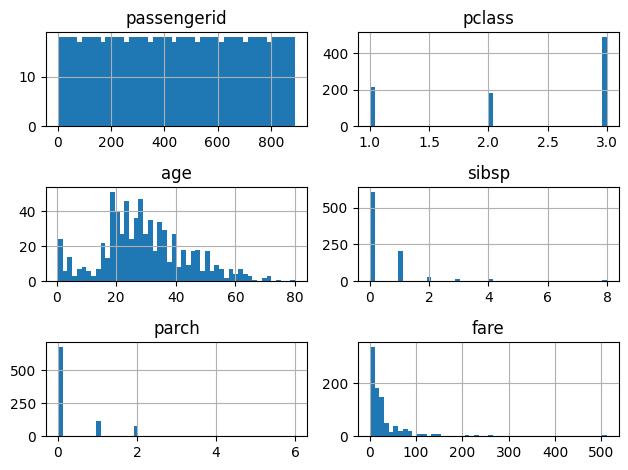

In [57]:
_ = X_train.hist(bins=50)
plt.tight_layout()

## Remove Null

In [122]:
X_train.isna().sum()[lambda x:x > 0]  # / len(X_train)

age         177
cabin       687
embarked      2
dtype: int64

In [123]:
X_train["embarked"] = X_train["embarked"].fillna("S")

age_med = X_train["age"].median()
X_train["age"] = X_train["age"].fillna(age_med)

## Extract Title & Create New Feature

### Extract Title

In [124]:
X_train["tname"] = X_train["name"].str.extract(r"(\w{2,})\.")
X_train["tname"] = X_train["tname"].replace("Mlle|Ms", "Miss", regex=True)
X_train["tname"] = X_train["tname"].replace("Mme", "Mrs", regex=True)
X_train["tname"] = X_train["tname"].replace(
    "Dr|Rev", "Prof", regex=True)  # Prof
X_train["tname"] = X_train["tname"].replace(
    "Capt|Major|Col", "Milt", regex=True)  # Milt
X_train["tname"] = X_train["tname"].replace(
    "Dona?|Sir|Lady|Countess|Jonkheer", "Nobl", regex=True)  # Nobl
X_train = X_train.drop(["name"], axis=1)

### Create Age Group

In [125]:
bins_age = [0, 13, 20, 65, np.inf]
labels_age = range(1, 5)

X_train['agegroup'] = pd.cut(
    X_train['age'], bins=bins_age, labels=labels_age, right=False).astype('int')

edf_train = pd.concat([X_train, y_train], axis=1)
edf_train.groupby(by="agegroup", observed=True)["survived"].mean()

agegroup
1    0.579710
2    0.410526
3    0.365922
4    0.090909
Name: survived, dtype: float64

### Other

In [126]:
X_train["tfamily"] = X_train["sibsp"] + X_train["parch"] + 1
X_train["isalone"] = X_train["tfamily"] == 1

## Encode Categories

In [127]:
X_train["sex"] = (X_train["sex"] == "male").astype(int)
X_train["sex"].value_counts()

sex
1    577
0    314
Name: count, dtype: int64

In [128]:
X_train = encode_OHE(X_train)

## Fix Skewness

In [129]:
fare_array = np.array(X_train["fare"]).reshape(-1, 1)
qt = QuantileTransformer(n_quantiles=500, output_distribution='normal')
X_train["fare"] = qt.fit_transform(fare_array)

In [130]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# import pandas as pd
# from sklearn.preprocessing import PowerTransformer, QuantileTransformer
# cols1 = ["fare", "age"]


# def test_transformers(columns):
#     pt = PowerTransformer()
#     qt = QuantileTransformer(n_quantiles=500, output_distribution='normal')
#     fig = plt.figure(figsize=(20, 30))
#     j = 1
#     for i in columns:
#         array = np.array(X_train[i]).reshape(-1, 1)
#         y = pt.fit_transform(array)
#         x = qt.fit_transform(array)
#         plt.subplot(3, 3, j)
#         sns.histplot(array, bins=50, kde=True)
#         plt.title(f"Original Distribution for {i}")
#         plt.subplot(3, 3, j+1)
#         sns.histplot(x, bins=50, kde=True)
#         plt.title(f"Quantile Transform for {i}")
#         plt.subplot(3, 3, j+2)
#         sns.histplot(y, bins=50, kde=True)
#         plt.title(f"Power Transform for {i}")
#         j += 3


# test_transformers(cols1)

## Remove outliers

### Isolation Forest

In [23]:
from sklearn.ensemble import IsolationForest
# Create an Isolation Forest model
# Adjust contamination based on your dataset
iso_forest = IsolationForest(contamination=0.05)
# Fit the model to your data
iso_forest.fit(X_train[["fare"]])
# Predict outliers
outliers = iso_forest.predict(X_train[["fare"]])

X_train = X_train.loc[outliers == 1]
y_train = y_train.loc[outliers == 1]
pd.Series(outliers).value_counts()

 1    847
-1     44
Name: count, dtype: int64

### Z_Score

In [24]:
from scipy.stats import zscore
# Calculate Z-scores for each data point
z_scores = zscore(X_train["fare"])
# Define a threshold for identifying outliers
threshold = 3
# Identify outliers
outliers = (z_scores > threshold) | (z_scores < -threshold)
X_train = X_train.loc[~outliers]
y_train = y_train.loc[~outliers]
pd.Series(outliers).value_counts()

False    847
Name: count, dtype: int64

### IQR

In [131]:
Q1 = X_train["fare"].quantile(0.25)
Q3 = X_train["fare"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = (X_train["fare"] < lower) | (upper < X_train["fare"])


X_train = X_train.loc[~outliers]
y_train = y_train.loc[~outliers]
outliers.value_counts()

fare
False    873
True      18
Name: count, dtype: int64

### Vis for Outliers

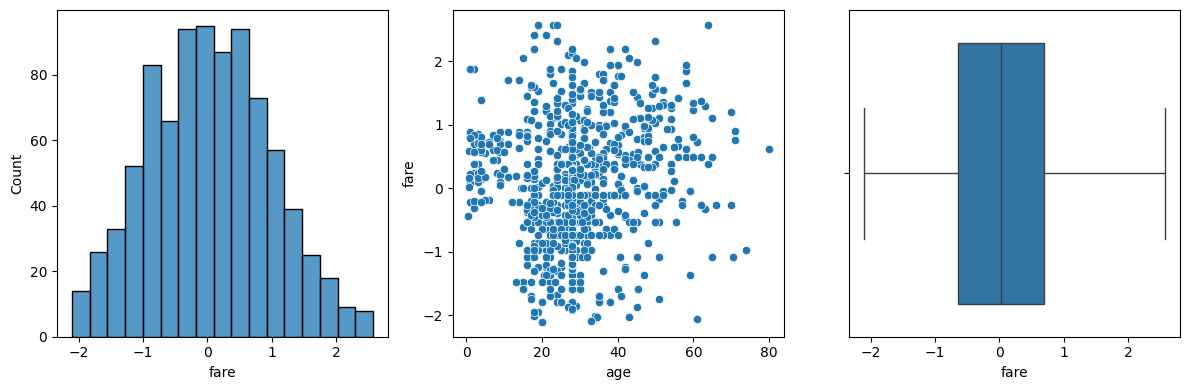

In [132]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.histplot(X_train["fare"], ax=axes[0])
sns.scatterplot(x=X_train["age"], y=X_train['fare'], ax=axes[1])
sns.boxplot(x=X_train["fare"], ax=axes[2])


plt.tight_layout()

## Feature Selection

In [133]:
scaler = MinMaxScaler()

scaled_X_train = scaler.fit_transform(X_train)
variance_cols = pd.Series(scaled_X_train.var(axis=0), index=X_train.columns)
dropped_col_fs = variance_cols[variance_cols < 0.16].index
X_fs = X_train.drop(dropped_col_fs, axis=1)

X_fs.columns

Index(['pclass', 'sex', 'isalone', 'cabin_nan', 'embarked_S', 'tname_Miss',
       'tname_Mr'],
      dtype='object')

## Train Model

In [101]:
models = {
    "RFC": RandomForestClassifier(),
    "XGBC": XGBClassifier(),
    "SVC": SVC(),
    "ABC": AdaBoostClassifier(),
    "GBC": GradientBoostingClassifier(),
    "CBC": CatBoostClassifier(verbose=0)
}

for model_name, model in models.items():
    clf = model
    model.fit(X_fs, y_train)
    models[model_name] = clf

## Measure Performance

In [102]:
for name_model, model in models.items():
    better = False
    y_hat = model.predict(X_fs)
    clf_cv = cross_val_score(model, X_fs, y_train, scoring="f1", cv=10)

    train_clf_score = round(f1_score(y_train, y_hat), 4)
    mean_clf_cv = round(clf_cv.mean(), 4)
    std_clf_cv = round(clf_cv.std(), 4)

    model_best_score = models_performance.get(name_model, 0)
    if model_best_score < mean_clf_cv:
        models_performance[name_model] = mean_clf_cv
        better = True

    diff_model_score = mean_clf_cv - model_best_score

    print(f"{name_model} F1 Score for Train : {train_clf_score}")
    print(f"{name_model} CV Mean({mean_clf_cv}), STD({std_clf_cv}) DIFF({diff_model_score}) Better({better})")

RFC F1 Score for Train : 0.7467
RFC CV Mean(0.7122), STD(0.0635) DIFF(-0.03649999999999998) Better(False)
XGBC F1 Score for Train : 0.75
XGBC CV Mean(0.7164), STD(0.0698) DIFF(-0.05559999999999998) Better(False)
SVC F1 Score for Train : 0.7356
SVC CV Mean(0.7259), STD(0.058) DIFF(-0.008600000000000052) Better(False)
ABC F1 Score for Train : 0.7349
ABC CV Mean(0.7179), STD(0.0411) DIFF(-0.04500000000000004) Better(False)
GBC F1 Score for Train : 0.7479
GBC CV Mean(0.7202), STD(0.0638) DIFF(-0.04910000000000003) Better(False)
CBC F1 Score for Train : 0.7467
CBC CV Mean(0.7201), STD(0.068) DIFF(-0.05349999999999999) Better(False)


In [103]:
with open(PATH_MODEL_PERFORMANCE, 'w') as file:
    dump(models_performance, file, indent=4)

## Prepare df_test

In [104]:
# drop not needed cols
df_test = df_test.drop([*DROPPED_COL], axis=1)

# Extract title from names
df_test["tname"] = df_test["name"].str.extract(r"(\w{2,})\.")
df_test["tname"] = df_test["tname"].replace("Mlle|Ms", "Miss", regex=True)
df_test["tname"] = df_test["tname"].replace("Mme", "Mrs", regex=True)
df_test["tname"] = df_test["tname"].replace(
    "Dr|Rev", "Prof", regex=True)  # Prof
df_test["tname"] = df_test["tname"].replace(
    "Capt|Major|Col", "Milt", regex=True)  # Milt
df_test["tname"] = df_test["tname"].replace(
    "Dona?|Sir|Lady|Countess|Jonkheer", "Nobl", regex=True)  # Nobl
df_test = df_test.drop(["name"], axis=1)

# fill null for age
df_test["age"] = df_test["age"].fillna(age_med)

# # create age bucket
df_test['agegroup'] = pd.cut(
    df_test['age'], bins=bins_age, labels=labels_age, right=False).astype('int')

# Create new feature
df_test["tfamily"] = df_test["sibsp"] + df_test["parch"] + 1
df_test["isalone"] = df_test["tfamily"] == 1

# fix skewness
fare_array = np.array(df_test["fare"]).reshape(-1, 1)
df_test["fare"] = qt.transform(fare_array)

# encode sex to true and false
df_test["sex"] = (df_test["sex"] == "male").astype("int")

# encdoe categorical cols
df_test = encode_OHE(df_test, fit=False)

df_test = df_test.drop(dropped_col_fs, axis=1)

In [105]:
df_test.columns, X_fs.columns

(Index(['pclass', 'sex', 'isalone', 'cabin_nan', 'embarked_S', 'tname_Miss',
        'tname_Mr'],
       dtype='object'),
 Index(['pclass', 'sex', 'isalone', 'cabin_nan', 'embarked_S', 'tname_Miss',
        'tname_Mr'],
       dtype='object'))

In [108]:
# create passenger_id start from 892 for df_test
passenger_id = df_test.index+892
# predict Survived from df_test
y_test_predicted = models["CBC"].predict(df_test)

# create df_test submission
pd.DataFrame({"PassengerId": passenger_id,
             "Survived": y_test_predicted}).to_csv("base_submit_1.csv", index=False)

In [ ]:
# 0.78708